# Introduction
When prompting this question "Which country is worth living in?" to Google search bar (or any AI-chatbot), the answers are almost always the same, you will see these countries: Norway, Denmark, Canada, Switzerland, etc. It is that easy to immediately know which country is good and which is bad. But, for me, it's just too shallow to take these search results for granted, I want to deeply understand:<br>
1. How are the countries ranked? Is the common way of ranking valid?<br>
2. Are the indicators really relevant (at least to me)?<br>
3. Are there any other way to rank these countries?<br>
4. What are countries similar to my country?<br>

My plan for this notebook:
- Collecting data from worldbank.org
- Providing deep analysis into some categories of indicators
- Performing dimension reduction (PC) to plot countries on a chart to compare countries across hundreds to thousands indicators
- Segmenting similar countries by performing k-mean clustering on principal components

First of all, the following are the categories of dicators we will look at:
- Poverty and economic development: how strong is the economy and is its wealth equally distributed.
- Health: even for a "rich" country, health can be overlooked. Especially for India, one of the largest economies with  the worst air quality.
- Wellbeings: this category consists of working hours, happiness index, human development index

In [39]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px
from sklearn.cluster import KMeans

In [2]:
# Helper function

def draw_scatter(df, title: str):
    cols = df.columns
    fig = px.scatter(
        df,
        x=cols[1],
        y=cols[2],
        hover_name=cols[0],
        hover_data={cols[1],
                    cols[2]},
        title=title
    )
    fig.show()

## 1. Poverty and economic development
The indicators we will look at including:
- GPD per capita converted by purchasing-power-parity (PPP): this measures a country economic output of each person, then adjusted for cost of living. This is better than raw GDP (which is overly used in mass media, in Vietnam at least) in my opinion, as it removes the difference in cost of living across countries. Do you know that you have to earn below $27.10 a day to labeled as "poor" in the U.S, which is the pay that you can live like a king in Vietnam?
- GDP per capita growth: this measures the growth rate of an economy
- Percentage of the population lives under the poverty line: the above metrics focus on the economy as a whole, if a country is rich (has high GDP), is this wealthiness distributed to poor people (by distributed I don't mean simply send cash to poor people, it could be in the form of investments, education, etc)?

In brief, we will look at metrics that measure how much the economy produce within a year (GDP), how much it grows in recent year, then how this country take care of the poorest segment?

In [ ]:
# Import GDP per capita PPP
gdp_ppp = pd.read_csv(
    "...gdp_ppp.csv")
columns_to_keep = ["REF_AREA_LABEL", "2024"]
gdp_ppp = gdp_ppp[columns_to_keep].dropna().rename(columns={"2024": "gdp_ppp"})

print("Highest GDP per capita")
display(gdp_ppp.sort_values(by="gdp_ppp", ascending=False).head(10))

print("Lowest GDP per capita")
display(gdp_ppp.sort_values(by="gdp_ppp", ascending=True).head(10))

Highest GDP per capita


,REF_AREA_LABEL,gdp_ppp
136,Luxembourg,150772.358842
194,Singapore,150689.301626
104,Ireland,131175.106854
138,"Macao SAR, China",128267.623420
186,Qatar,126110.108802
26,Bermuda,119718.584668
165,Norway,101031.587517
36,Switzerland,93818.707481
30,Brunei Darussalam,90007.077486
237,United States,85809.900385


Lowest GDP per capita


,REF_AREA_LABEL,gdp_ppp
15,Burundi,949.834613
33,Central African Republic,1263.595543
199,Somalia,1600.763621
154,Mozambique,1699.705034
41,"Congo, Dem. Rep.",1709.732077
157,Malawi,1859.447961
141,Madagascar,1883.537431
124,Liberia,1884.913143
161,Niger,2015.022821
192,Sudan,2127.400391


In [ ]:
# Import GDP per capita growth
gdp_growth = pd.read_csv(
    "...gdp_growth.csv")
gdp_growth = gdp_growth[columns_to_keep].sort_values(
    by="2024", ascending=False).dropna().rename(columns={"2024": "gdp_growth"})

# Draw scatter plot between GDP per capita and GDP growth
gdp_growth_ppp = pd.merge(
    gdp_ppp, gdp_growth, on="REF_AREA_LABEL", how="inner")
draw_scatter(gdp_growth_ppp, "GDP per capita vs GDP growth")

In [ ]:
# Import the percentage of population living in multi-dimensional poverty.
pop_under_poverty = pd.read_csv(
    "...poverty_rate.csv")
pop_under_poverty = pop_under_poverty[pop_under_poverty["VINTAGE_LABEL"]
                                      == "Vintage: 2025 Annual Meetings"]
pop_under_poverty = pop_under_poverty[["REF_AREA_LABEL", "2024"]].reset_index(
    drop=True).sort_values(by="2024", ascending=False).dropna()

display("10 countries with highest poverty rate")
display(pop_under_poverty.head(10))

display("10 countries with lowest poverty rate")
display(pop_under_poverty.tail(10))

'10 countries with highest poverty rate'

,REF_AREA_LABEL,2024
85,South Sudan,84.025283
18,"Congo, Dem. Rep.",81.659359
62,Mozambique,81.007872
65,Malawi,76.347156
4,Burundi,74.781621
102,Zambia,70.634461
14,Central African Republic,67.511360
57,Madagascar,66.825240
79,Sudan,59.432124
98,Uganda,56.954575


'10 countries with lowest poverty rate'

,REF_AREA_LABEL,2024
39,Croatia,0.256067
61,Mongolia,0.209411
99,Uruguay,0.167160
56,Moldova,0.129222
77,Russian Federation,0.088514
96,Turkiye,0.075184
52,St. Lucia,0.022596
12,Bhutan,0.005671
66,Malaysia,0.001828
93,Thailand,0.001149


Instead of looking at mere monetary porverty, which overlooks other important aspects human life, the multi-dimensional poverty index measures comprehensive living standards for people in poverty , such as access to water, transportation, education opportunity, etc. Neverthless, the dataset is quite limit with only 103 countries report the metric. Therefore, I will perform two PCAs, with one including and the other excluding this metric.

## 2. Health
In this section, we will look at the following indicators:
- Life expectancy at age 60: estimates the average number of additional years a person aged 60 can expect to live.
- Child and infant mortality: this measures the number of children under 5 and infant per 1000 that are deceased within a year.
- Percentage of people exposed to hazardous air quality

Countries that score better at these metrics might demonstrate better health care system, focus of investments on reducing enviromental pollution.

In [ ]:
# Import life expectancy
life_expect = pd.read_csv(
    "...life_expect.csv")
life_expect = life_expect[["REF_AREA_LABEL", "SEX", "2021"]]

In [7]:
life_expect_male = life_expect[life_expect["SEX"]
                               == "M"].sort_values(by="2021", ascending=True)
life_expect_female = life_expect[life_expect["SEX"]
                                 == "F"].sort_values(by="2021", ascending=True)
display("Male")
display(life_expect_male.head(10))
display(life_expect_male.tail(10))
display("Female")
display(life_expect_female.head(10))
display(life_expect_female.tail(10))

'Male'

,REF_AREA_LABEL,SEX,2021
51,Bolivia,M,11.5679
277,Namibia,M,11.5934
227,Lesotho,M,11.6145
365,Eswatini,M,11.7307
267,Mozambique,M,12.2617
243,Moldova,M,12.3546
61,Botswana,M,12.4733
63,Central African Republic,M,12.6577
431,Zimbabwe,M,12.8177
429,Zambia,M,12.9821


,REF_AREA_LABEL,SEX,2021
363,Sweden,M,23.5659
65,Canada,M,23.7816
289,Norway,M,23.8141
195,Japan,M,24.0491
67,Switzerland,M,24.1876
295,New Zealand,M,24.2568
163,"Hong Kong SAR, China",M,24.5934
21,Australia,M,24.8146
235,"Macao SAR, China",M,24.8551
241,Monaco,M,25.7099


'Female'

,REF_AREA_LABEL,SEX,2021
282,Nigeria,F,14.3380
226,Lesotho,F,14.3564
374,Chad,F,14.4042
266,Mozambique,F,14.7597
254,Mali,F,14.8592
62,Central African Republic,F,14.8660
348,Somalia,F,14.9906
398,Uganda,F,14.9949
364,Eswatini,F,15.0251
32,Burkina Faso,F,15.0446


,REF_AREA_LABEL,SEX,2021
66,Switzerland,F,27.3505
116,Spain,F,27.4128
256,Malta,F,27.5030
126,France,F,27.5777
312,Puerto Rico,F,27.5991
208,"Korea, Rep.",F,28.2936
240,Monaco,F,28.9232
234,"Macao SAR, China",F,29.0917
194,Japan,F,29.2835
162,"Hong Kong SAR, China",F,29.4161


In [ ]:
# Import infant mortality rate (5-14 year olds per 1000 children at age of 5)
child_mortal = pd.read_csv(
    "...child_mortality_rate.csv")
child_mortal = child_mortal[["REF_AREA_LABEL", "2023"]]
display(child_mortal.sort_values(by="2023", ascending=False).head(10))
display(child_mortal.sort_values(by="2023", ascending=True).head(10))

,REF_AREA_LABEL,2023
131,Niger,30.099826
150,West Bank and Gaza,28.121979
101,Libya,23.573268
161,Sierra Leone,23.199565
164,Somalia,23.099443
166,South Sudan,21.993648
28,Central African Republic,21.367283
177,Chad,20.931772
119,Mali,19.490361
34,Cameroon,19.015819


,REF_AREA_LABEL,2023
163,San Marino,0.435517
108,Luxembourg,0.449304
84,Iceland,0.495756
81,Ireland,0.604587
47,Denmark,0.608105
171,Slovenia,0.648375
63,United Kingdom,0.666119
172,Sweden,0.683131
88,Jordan,0.686895
30,Switzerland,0.694761


In [ ]:
# Import infant mortality (0-5 year olds per 1000 live births)
infant_mortal = pd.read_csv(
    "...infant_mortality_rate.csv")
infant_mortal = infant_mortal[["REF_AREA_LABEL", "2023"]]
display(infant_mortal.sort_values(by="2023", ascending=False).head(10))
display(infant_mortal.sort_values(by="2023", ascending=True).head(10))

,REF_AREA_LABEL,2023
132,Niger,114.800003
133,Nigeria,104.900002
165,Somalia,104.000000
178,Chad,101.099998
167,South Sudan,98.699997
66,Guinea,95.000000
162,Sierra Leone,94.300003
28,Central African Republic,92.199997
120,Mali,91.300003
13,Benin,77.900002


,REF_AREA_LABEL,2023
164,San Marino,1.4
56,Estonia,2.1
160,Singapore,2.1
172,Slovenia,2.2
58,Finland,2.3
109,Luxembourg,2.3
136,Norway,2.4
89,Japan,2.4
20,Belarus,2.4
173,Sweden,2.5


In [ ]:
# Import air quality
air_quality = pd.read_csv(
    "...air_quality.csv")
air_quality = air_quality[["REF_AREA_LABEL", "2023"]].dropna()

display(air_quality.sort_values(by="2023", ascending=False).head(10))
display(air_quality.sort_values(by="2023", ascending=True).head(10))

,REF_AREA_LABEL,2023
92,Niger,99.3
59,Iraq,98.7
10,Bangladesh,98.6
87,Mauritania,98.5
156,"Yemen, Rep.",97.9
93,Nigeria,95.3
24,Cameroon,93.6
97,Pakistan,91.9
109,Senegal,91.8
31,Djibouti,82.6


,REF_AREA_LABEL,2023
159,Zimbabwe,0.0
66,Kiribati,0.0
65,Cambodia,0.0
64,Kyrgyz Republic,0.0
103,Poland,0.0
60,Jamaica,0.0
104,Paraguay,0.0
105,Romania,0.0
67,St. Kitts and Nevis,0.0
106,Russian Federation,0.0


# 3. Well-beings
Indicators in this category including:
- Average annual working hour: this measures how much an average worker works in a year
- Happiness index: the average answer people provided to the question “Please imagine a ladder, with steps numbered from 0 at the bottom to 10 at the top. The top of the ladder represents the best possible life for you, and the bottom of the ladder represents the worst possible life for you. On which step of the ladder would you say you personally feel you stand at this time?”
- Human development index: this metric measures multiple things at once, life expectancy at birth, expected years of schooling, average years of schooling, gross national income. Ranging from 0-1, the closer to 1, the better.

In [ ]:
# Import annual working hour
working_hour = pd.read_csv(
    "...working_hour.csv")
working_hour = working_hour[working_hour["Year"] == 2023]
working_hour = working_hour[["Entity", "Average working hours per worker"]]
working_hour_gdp = pd.merge(
    working_hour, gdp_ppp, left_on="Entity", right_on="REF_AREA_LABEL", how="inner")
working_hour_gdp = working_hour_gdp.drop('REF_AREA_LABEL', axis=1)
working_hour_gdp.rename(columns={"2024": "GDP per capita"}, inplace=True)
draw_scatter(working_hour_gdp, "Working hour vs GDP")

The clear winners from this chart are Ireland and Luxembourg, which very high productivity, they have the almost lowest number of annual working hour, yet maintain a very high GDP percapita.

In [ ]:
# Import happiness index
happiness_ind = pd.read_csv(
    "...happiness.csv")
happiness_ind = happiness_ind[["Entity", "Cantril ladder score"]]
happiness_ind_gdp = pd.merge(
    happiness_ind, gdp_ppp, left_on="Entity", right_on="REF_AREA_LABEL", how="inner")
happiness_ind_gdp.rename(columns={
                         "2024": "GDP per capita", "Cantril ladder score": "Happiness"}, inplace=True)
happiness_ind_gdp = happiness_ind_gdp.drop('REF_AREA_LABEL', axis=1)


draw_scatter(happiness_ind_gdp, "Happiness vs GDP")

In [ ]:
# Import HDI
hdi = pd.read_csv(
    "...hdi.csv")
hdi = hdi[["Entity", "Human Development Index"]]
hdi.sort_values(by="Human Development Index", ascending=False).head(
    10)  # Top 10 countries with highest HDI

,Entity,Human Development Index
76,Iceland,0.972
167,Switzerland,0.970
127,Norway,0.970
46,Denmark,0.962
65,Germany,0.959
166,Sweden,0.959
8,Australia,0.958
121,Netherlands,0.955
16,Belgium,0.951
81,Ireland,0.949


# 4. PCA and clustering
So far, across almost all metrics, the Europeans outperform other countries. In order to plot and compare the countries for all the metrics, we need to first reduce the dimensions using PCA, then plot only the first two principal components.

In [14]:
# Merge datasets for PCA and clustering
gdp_final = pd.merge(gdp_ppp, gdp_growth, on="REF_AREA_LABEL",
                     how="inner", suffixes=("_gdp", "_growth"))
life_expect = pd.merge(life_expect_male, life_expect_female,
                       on="REF_AREA_LABEL", how="inner")
gdp_and_life_expect = pd.merge(
    gdp_final, life_expect, on="REF_AREA_LABEL", how="inner")
gdp_life_infant = pd.merge(
    gdp_and_life_expect, infant_mortal, on="REF_AREA_LABEL", how="inner")
gdp_life_infant_child = pd.merge(
    gdp_life_infant, child_mortal, on="REF_AREA_LABEL", how="inner")
gdp_life_infant_child_working = pd.merge(
    gdp_life_infant_child, working_hour, left_on="REF_AREA_LABEL", right_on="Entity", how="inner")
gdp_life_infant_child_working_happy = pd.merge(
    gdp_life_infant_child_working, happiness_ind, left_on="REF_AREA_LABEL", right_on="Entity", how="inner")
gdp_life_infant_child_working_happy_hdi = pd.merge(
    gdp_life_infant_child_working_happy, hdi, left_on="REF_AREA_LABEL", right_on="Entity", how="inner")
gdp_life_infant_child_working_happy_hdi.rename(columns={"2024_gdp": "gdp_per_capita", "2024_growth": "gdp_growth",
                                                        "2021_x": "life_expect", "2021_y": "infant_mortal", "2023_y": "child_mortal",
                                                        "Cantril ladder score": "Happiness", "Average working hours per worker": "working_hours", "REF_AREA_LABEL": "Countries", "Human Development Index": "hdi"}, inplace=True)

final_table = gdp_life_infant_child_working_happy_hdi[["Countries", "gdp_ppp", "gdp_growth",
                                                       "life_expect", "infant_mortal", "child_mortal", "working_hours", "hdi"]]
final_table

,Countries,gdp_ppp,gdp_growth,life_expect,infant_mortal,child_mortal,working_hours,hdi
0,Angola,8347.952791,1.292933,14.0261,16.2364,14.528218,2114.50,0.616
1,Albania,23488.098947,5.663959,18.6623,22.1905,1.700976,2151.97,0.810
2,United Arab Emirates,77958.895409,-0.766019,19.9832,23.0163,1.274969,2514.45,0.940
3,Argentina,30175.535966,-1.683527,17.6209,22.6760,2.040193,1612.12,0.865
4,Armenia,22823.179526,3.484216,13.2565,20.6109,2.112268,1976.15,0.811
...,...,...,...,...,...,...,...,...
108,United States,85809.900385,1.794192,20.8873,24.4087,1.469259,1788.88,0.938
109,Uzbekistan,11878.552871,4.421798,14.6608,17.7543,4.999969,2098.62,0.740
110,South Africa,15457.489145,-0.713538,13.1296,16.3212,5.652462,2181.43,0.741
111,Zambia,4223.950208,0.941473,12.9821,15.4326,9.241346,2199.55,0.595


In [17]:
# Standardized features
nu_cols = ['gdp_ppp', 'gdp_growth', 'life_expect',
           'infant_mortal', 'child_mortal', 'working_hours', 'hdi']
final_table.loc[:, nu_cols] = StandardScaler(
).fit_transform(final_table[nu_cols])

In [ ]:
# Perform PCA
pca = PCA(n_components=0.95)
final_pca = pca.fit_transform(final_table[nu_cols])

var_ratio = pca.explained_variance_ratio_
pc1_var = var_ratio[0] * 100
pc2_var = var_ratio[1] * 100
first_2 = pc1_var + pc2_var
pca_df = pd.DataFrame(
    final_pca[:, :2],
    columns=[f"PC1 ({pc1_var:.1f}% var)", f"PC2 ({pc2_var:.1f}% var)"]
)
pca_df = pd.DataFrame(final_pca[:, :2], columns=["PC1", "PC2"])
pca_df["Countries"] = final_table["Countries"].astype(str)
pca_df = pca_df[["Countries", "PC1", "PC2"]]

print(
    f"The first two principal components retains {first_2:.2f}% of the variability in data")
draw_scatter(pca_df, "Countries in PC space")

The first two principal components retains 74.95% of the variability in data


Even though the variability in the dataset retained by the first two principal components is not too high (at 74.95%), we can still see the usual suspects. The "good" European countries are closed together, the South Americans and Asians are in the middle, then comes the Africans. Next, I will try performing k-means clustering on these countries, using the first three principal components.

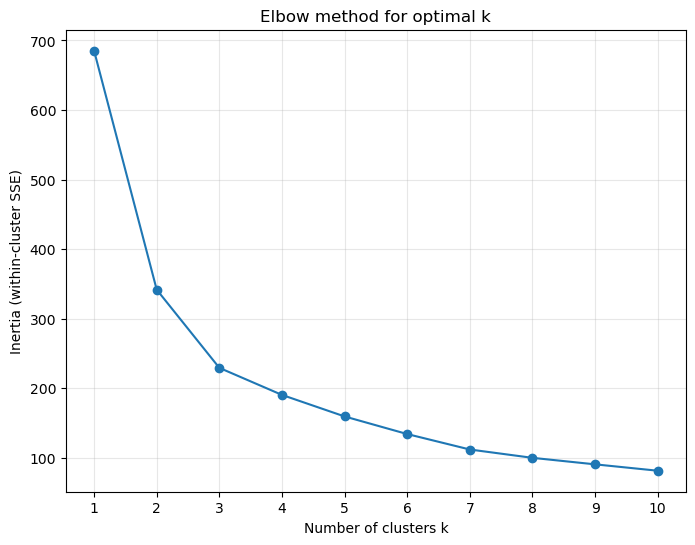

In [33]:
# Prepare data for k-means clustering
pc3_var = var_ratio[2] * 100
pca_clustering = pd.DataFrame(
    final_pca[:, :3],
    columns=[f"PC1 ({pc1_var:.1f}% var)",
             f"PC2 ({pc2_var:.1f}% var)", f"PC3 ({pc3_var:.1f}% var)"]
)
pca_clustering["Countries"] = final_table["Countries"].astype(str)
pc_cols = [
    "PC1 (60.4% var)",
    "PC2 (14.5% var)",
    "PC3 (11.7% var)"
]
X_pc = pca_clustering[pc_cols]
inertias = []
k_values = range(1, 11)

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=25)
    km.fit(X_pc)
    # sum of squared distances to cluster centers
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(k_values, inertias, marker='o')
plt.xticks(k_values)
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow method for optimal k")
plt.grid(True, alpha=0.3)
plt.show()
# Optimal k at 3

kmeans = KMeans(n_clusters=3, random_state=42, n_init=25)
pca_clustering["cluster"] = kmeans.fit_predict(X_pc)

In [37]:
# Show the countries again with clusters
pca_df.loc[:, "Cluster"] = pca_clustering["cluster"]
final_fig = px.scatter(
    pca_df,
    x="PC1",
    y="PC2",
    hover_name="Countries",
    hover_data={"PC1",
                "PC2"},
    color="Cluster",
    title="Clusters of countries"
)
final_fig.show()

In [ ]:
# Extract features that construct the first components
pc1_loadings = pca.components_[0]
loadings_df = pd.DataFrame({
    "feature": nu_cols,
    "loading": pc1_loadings,
    "abs_loading": np.abs(pc1_loadings)
})
loadings_df = loadings_df.sort_values("abs_loading", ascending=False)

print(loadings_df.head(10))

         feature   loading  abs_loading
3  infant_mortal -0.462625     0.462625
6            hdi -0.453789     0.453789
2    life_expect -0.436639     0.436639
0        gdp_ppp -0.422704     0.422704
4   child_mortal  0.369055     0.369055
5  working_hours  0.260069     0.260069
1     gdp_growth  0.082970     0.082970


We can see that the "health-related" metrics (and GDP per capita) contribute heavily to the construct of the first component, over which the countries data mainly spread. For the case of the Europeans, we can say that these countries performs best in these metrics, which seperate them from the rest.

# Data source
World Bank: https://data.worldbank.org/<br>
Our World in data: https://ourworldindata.org/